In [1]:
import numpy as np

path0 = './'
filename = 'syntax_matched_sentences.txt'
threshold = 0.4  # adjust this value as needed

data = []
with open(f"{path0}{filename}", "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 5:
            sentence1, sentence2, tags1, tags2, word_overlap = parts
            try:
                if float(word_overlap) < threshold and tags1 == tags2:
                    data.append((sentence1, sentence2, tags1, word_overlap))
            except ValueError:
                continue  # skip lines with non-numeric word_overlap

print(f'{len(data)=}')
print(data[-1])

# removing entries with tag counts less than 5
from collections import Counter
tag_counts = Counter(tags for _, _, tags, _ in data)
data = [entry for entry in data if tag_counts[entry[2]] > 5]

print(f"Filtered size: {len(data)}")

len(data)=2369
('The old tradition and a custom changed gradually', 'The soft pillow and a blanket lay comfortably', 'DT JJ NN CC DT NN VBD RB', '0.375')
Filtered size: 2098


In [2]:
# Export sentences from the filtered dataset to sentences0.txt and sentences1.txt

sentences0 = [entry[0] for entry in data]
sentences1 = [entry[1] for entry in data]

with open('sentences0.txt', 'w') as f0:
  for sentence in sentences0:
    f0.write(sentence + '\n')

with open('sentences1.txt', 'w') as f1:
  for sentence in sentences1:
    f1.write(sentence + '\n')

len(unique_tags)=96


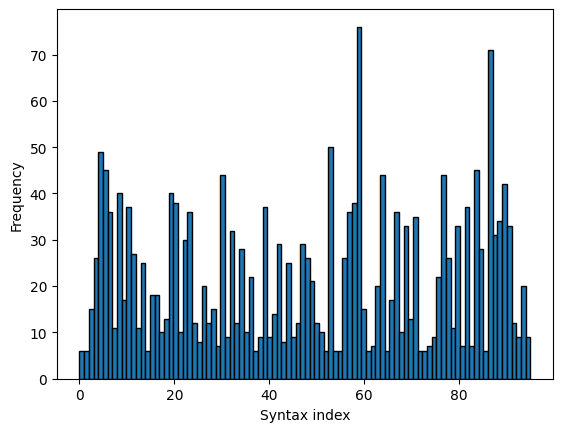

In [3]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1)
# Assign an index to each unique tag in data
unique_tags = sorted(set(entry[2] for entry in data))
tag_to_index = {tag: idx for idx, tag in enumerate(unique_tags)}

# Get the list of tag indices for all entries in data
tag_indices = [tag_to_index[entry[2]] for entry in data]

# Plot histogram of tag indices
ax.hist(tag_indices, bins=len(unique_tags), edgecolor='black')
plt.xlabel('Syntax index')
plt.ylabel('Frequency')
# plt.title('Histogram of syntax structures in data')
fig.savefig('syntax_pos_frequencies.pdf', bbox_inches='tight')
print(f'{len(unique_tags)=}')
plt.show()

In [4]:
np.savetxt('group_ids.txt',tag_indices,fmt='%d')

In [8]:
# Check if each sentence in sentences0 is also present in sentences1
sentences1_set = set(sentences1)
sentences0_in_1 = [sentence in sentences1_set for sentence in sentences0]

# Print summary
num_present = sum(sentences0_in_1)
print(f"{num_present} out of {len(sentences0)} sentences from sentences0.txt are present in sentences1.txt")

2063 out of 2098 sentences from sentences0.txt are present in sentences1.txt


### Semantic ablation

I have to filter syntax pairs for which I have their semantic vectors

In [14]:
# filenames
file_a = "sentences0.txt"
file_b = "/home/acevedo/syn-sem/datasets/txt/sem/second/matching/english/sentences0.txt"
output_file_a = "syn_ids_with_sem.txt"
output_file_b = "sem_centers_ids.txt"

# read files
with open(file_a, "r", encoding="utf-8") as f:
    sentences_a = [line.strip() for line in f]

with open(file_b, "r", encoding="utf-8") as f:
    sentences_b = [line.strip() for line in f]

# create dictionary mapping sentence -> index in file_b
sentence_to_index_b = {s: i for i, s in enumerate(sentences_b)}

# find matching indices
matches_a = [i for i, s in enumerate(sentences_a) if s in sentence_to_index_b]
matches_b = [sentence_to_index_b[s] for s in sentences_a if s in sentence_to_index_b]

# save file_a indices
with open(output_file_a, "w", encoding="utf-8") as f:
    for idx in matches_a:
        f.write(f"{idx}\n")

# save file_b indices
with open(output_file_b, "w", encoding="utf-8") as f:
    for idx in matches_b:
        f.write(f"{idx}\n")

print(f"Saved {len(matches_a)} indices from file_a to {output_file_a}")
print(f"Saved {len(matches_b)} indices from file_b to {output_file_b}")


Saved 1584 indices from file_a to syn_ids_with_sem.txt
Saved 1584 indices from file_b to sem_centers_ids.txt
